Intro to KNN Regression – Real Estate Price Prediction

In this section, K-Nearest Neighbors Regression (KNN Regressor) is applied to predict house prices using the Real-estate-dataset.csv. The objective is to estimate the price variable based on features such as transaction date (X1), house age (X2), distance to the nearest MRT station (X3), number of convenience stores (X4), latitude (X5), and longitude (X6). The workflow involves loading and exploring the dataset, defining the feature set (X_reg) and target variable (y_reg), and applying feature scaling to ensure accurate distance-based computations. A KNeighborsRegressor model is then trained on the processed data and evaluated using metrics such as RMSE and R². Additional visualizations, including actual vs. predicted plots and residual analysis, are used to assess model performance. KNN Regression operates by identifying the K most similar data points (neighbors) and predicting the target value as the average of their corresponding outputs.

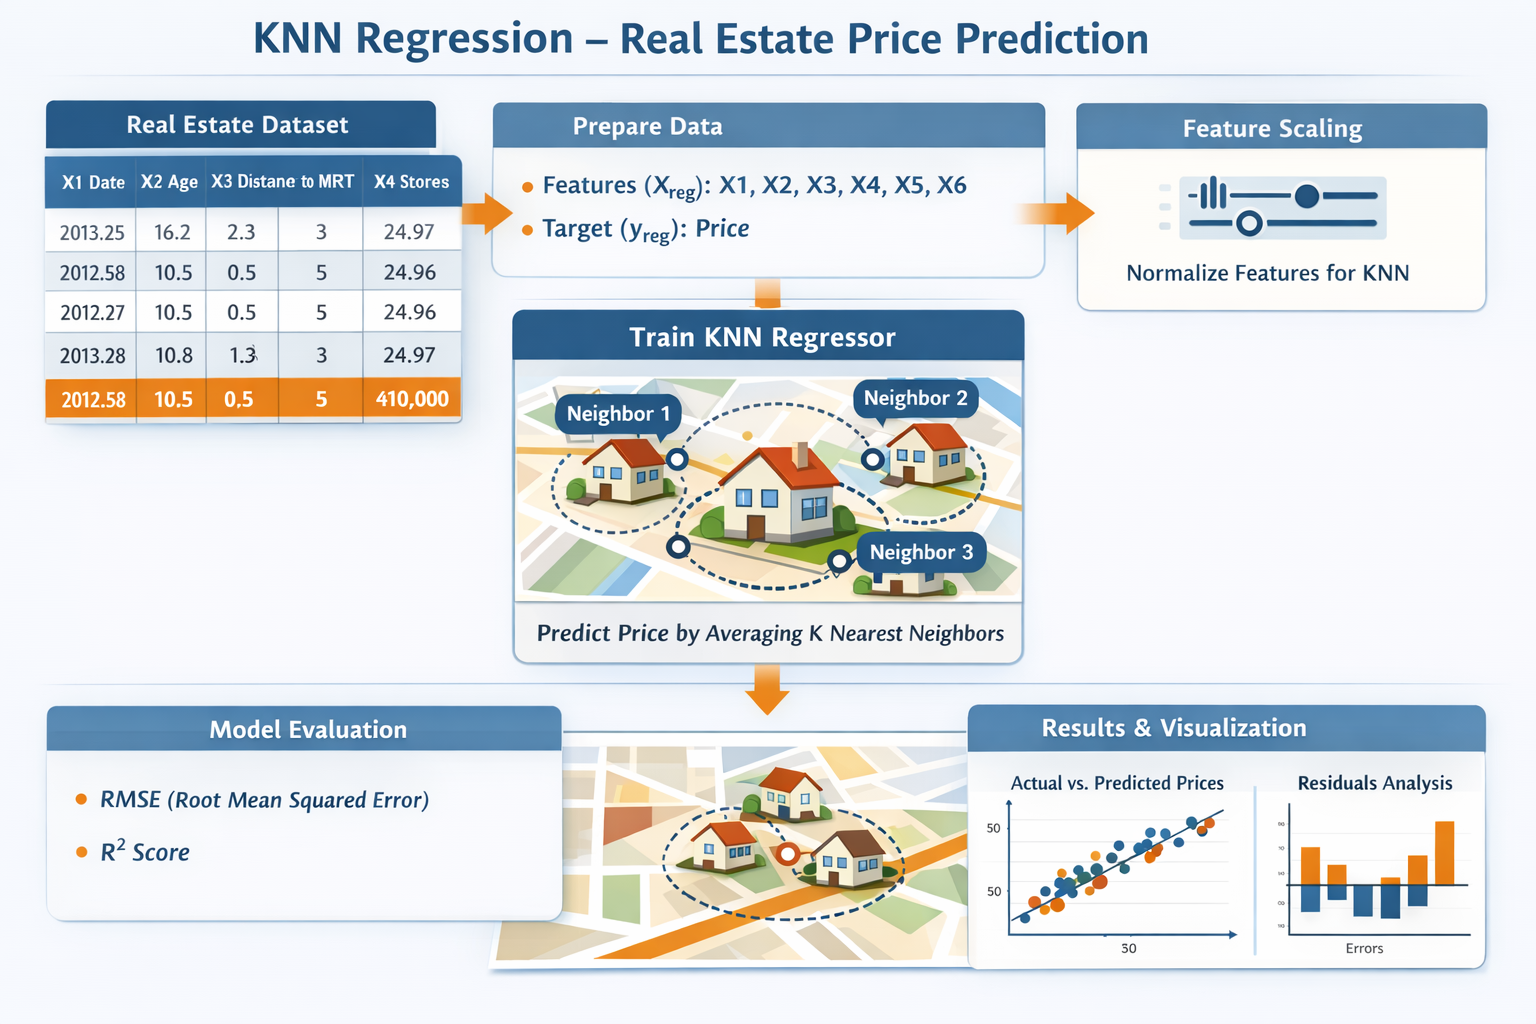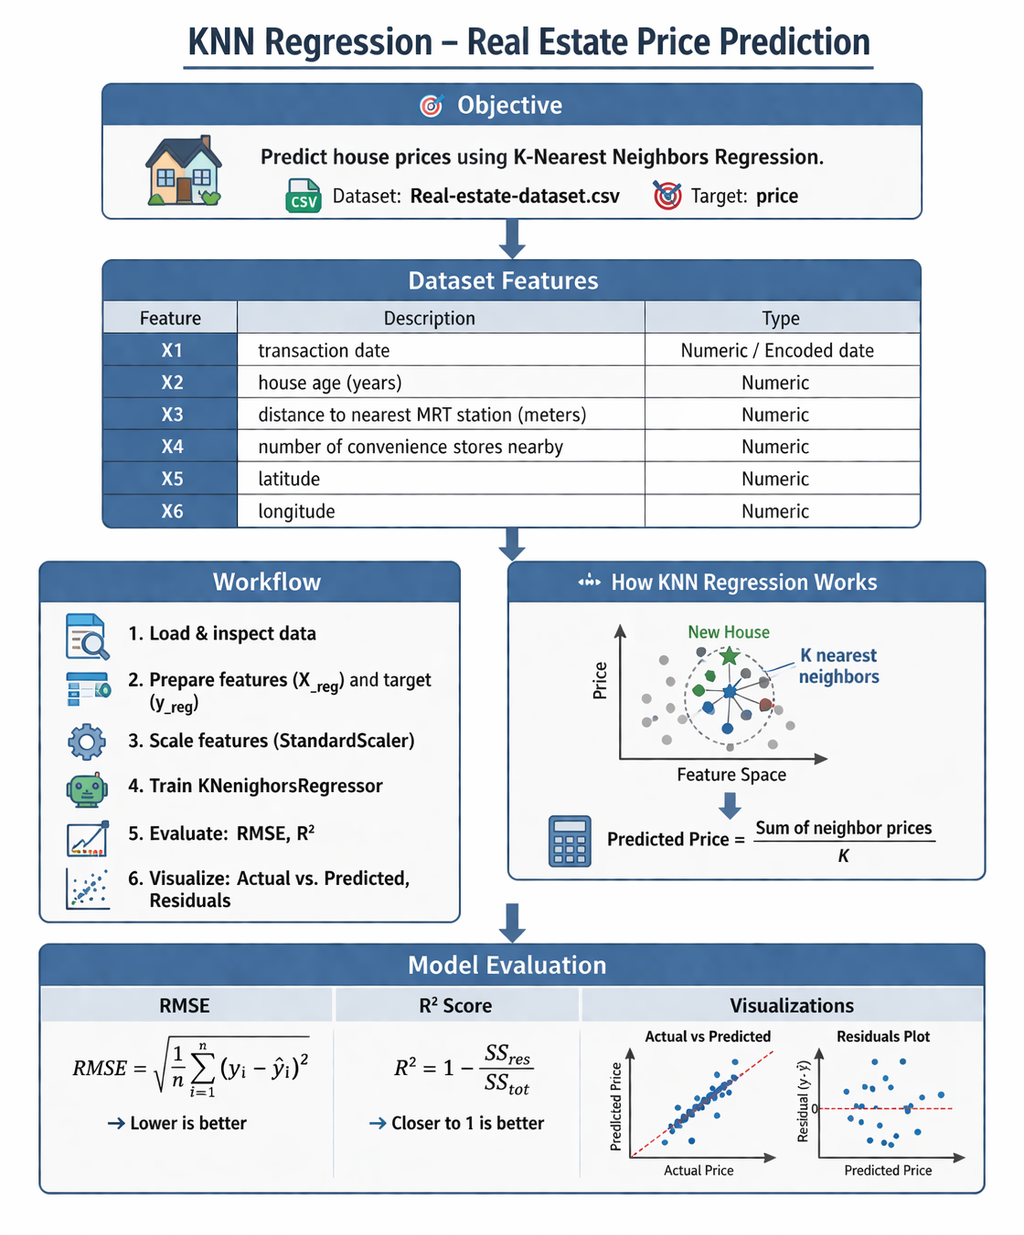

In [1]:
import pandas as pd

# Load Real Estate dataset
real_estate_df = pd.read_csv("/content/Real-estate-dataset.csv")

print(real_estate_df.head())
print(real_estate_df.info())


   price  No  X1 transaction date  X2 house age  \
0   37.9   1             2012.917          32.0   
1   42.2   2             2012.917          19.5   
2   47.3   3             2013.583          13.3   
3   54.8   4             2013.500          13.3   
4   43.1   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  
0     24.98298     121.54024  
1     24.98034     121.53951  
2     24.98746     121.54391  
3     24.98746     121.54391  
4     24.97937     121.54245  
<class 'pandas.core.frame.DataFrame'>


In [2]:
# Drop index-like column
real_estate_df = real_estate_df.drop(columns=["No"])

# Target and features
y_reg = real_estate_df["price"]
X_reg = real_estate_df.drop(columns=["price"])

print("Features shape:", X_reg.shape)
print("Target shape:", y_reg.shape)
X_reg.head()

Features shape: (414, 6)
Target shape: (414,)


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


Train/Test Split + Scaling (Regression)

The dataset is divided into training and testing subsets to enable proper model validation on unseen data. Following the split, feature scaling is applied using StandardScaler to normalize the input variables. Since KNN relies on distance-based computations (e.g., Euclidean distance), scaling ensures that all features contribute equally, preventing variables with larger magnitudes from disproportionately influencing the model.

Train KNN Regressor

A K-Nearest Neighbors Regressor is then initialized and trained on the scaled training data. The model is configured with n_neighbors = 5, meaning that the predicted house price is computed as the average of the five closest data points in the feature space. This approach allows the model to capture local patterns and similarities among nearby observations.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale features
reg_scaler = StandardScaler()
X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train)
X_reg_test_scaled = reg_scaler.transform(X_reg_test)


In [7]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",   # closer neighbors have more influence
    metric="minkowski"    # default (Euclidean for p=2)
)

knn_reg.fit(X_reg_train_scaled, y_reg_train)

print("KNN Regressor training complete.")


KNN Regressor training complete.


Evaluate KNN Regression

The performance of the KNN Regression model is assessed using key evaluation metrics and visualization techniques. RMSE (Root Mean Squared Error) measures the typical prediction error in the same units as house prices, providing an interpretable estimate of how far predictions deviate from actual values. The R² score indicates the proportion of variance in the target variable explained by the model, reflecting its overall explanatory power.

To further analyze performance, visualizations are used. The Actual vs. Predicted plot compares predicted prices with true values, where points close to the reference line indicate accurate predictions. The Residual plot displays the differences between actual and predicted values, helping identify patterns, bias, or inconsistencies in model errors.

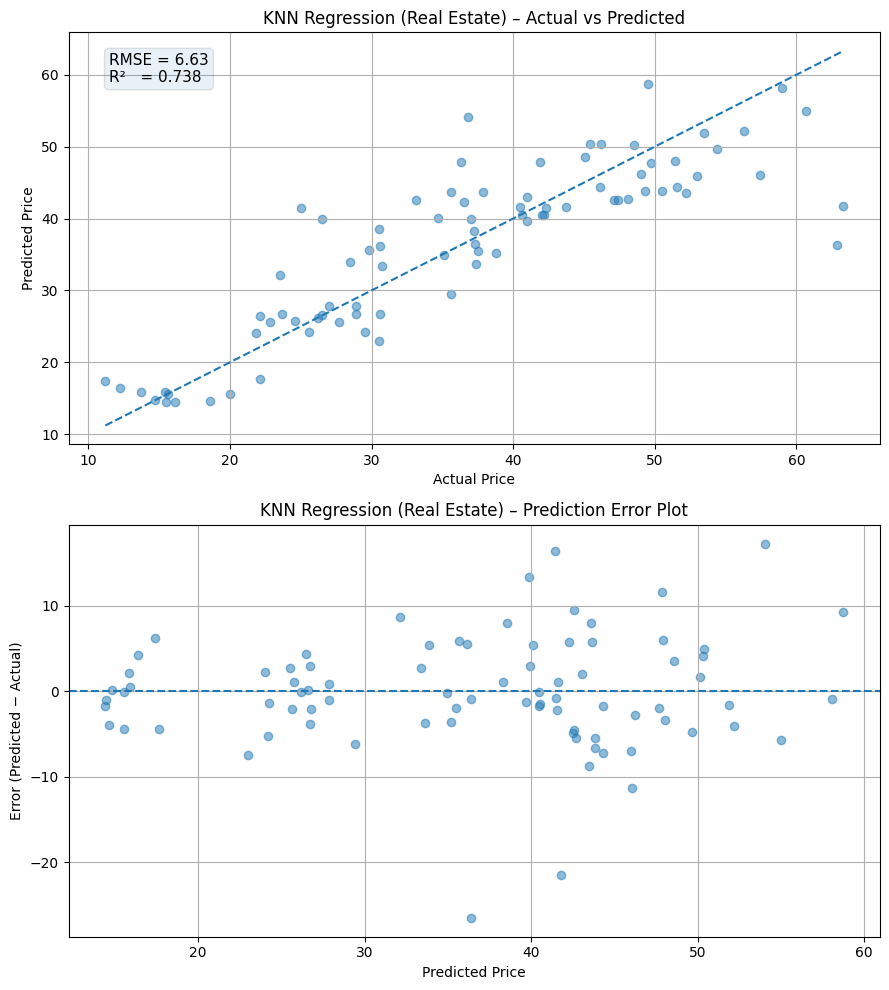

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def knn_regression_diagnostics(y_true, y_pred, title_prefix="KNN Regression"):
    # Ensure arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Prediction error
    error = y_pred - y_true

    fig, axes = plt.subplots(2, 1, figsize=(9, 10))

    # --- 1) Actual vs Predicted ---
    ax1 = axes[0]
    ax1.scatter(y_true, y_pred, alpha=0.5)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax1.set_xlabel("Actual Price")
    ax1.set_ylabel("Predicted Price")
    ax1.set_title(f"{title_prefix} – Actual vs Predicted")
    ax1.grid(True)

    # Metrics box
    textstr = f"RMSE = {rmse:.2f}\nR²   = {r2:.3f}"
    ax1.text(
        0.05, 0.95, textstr,
        transform=ax1.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.1)
    )

    # --- 2) Prediction Error vs Predicted ---
    ax2 = axes[1]
    ax2.scatter(y_pred, error, alpha=0.5)
    ax2.axhline(0, linestyle="--")
    ax2.set_xlabel("Predicted Price")
    ax2.set_ylabel("Error (Predicted − Actual)")
    ax2.set_title(f"{title_prefix} – Prediction Error Plot")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Make predictions on the scaled test set
y_reg_pred_knn = knn_reg.predict(X_reg_test_scaled)

# Use it like this:
knn_regression_diagnostics(y_reg_test, y_reg_pred_knn, title_prefix="KNN Regression (Real Estate)")

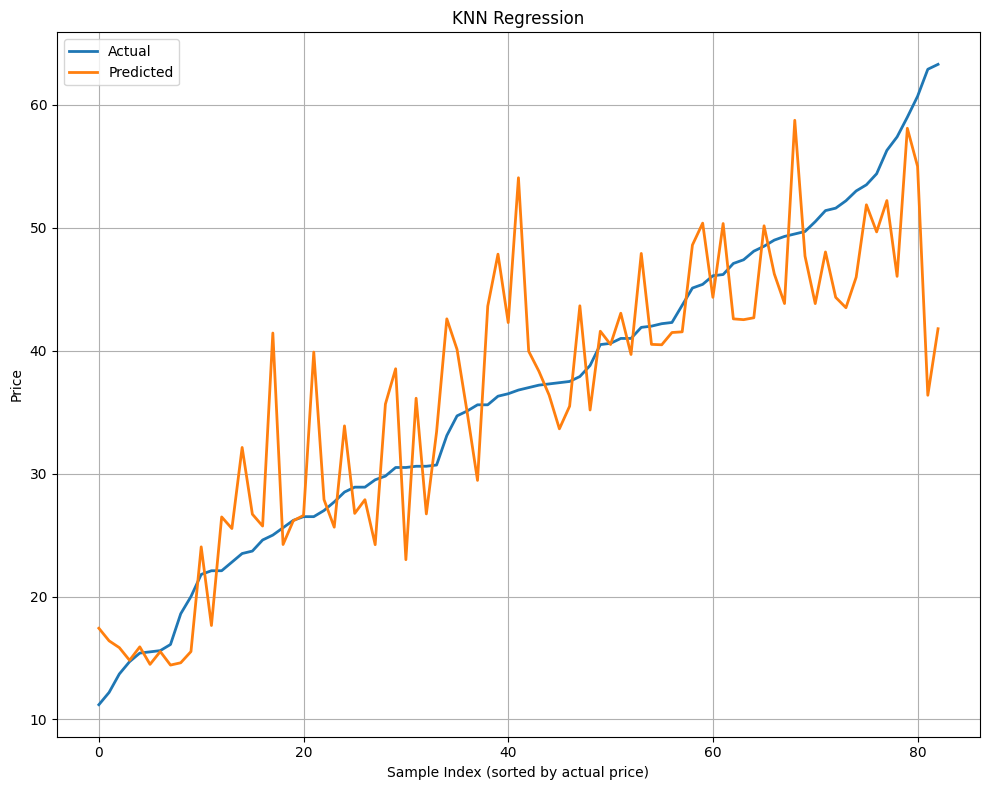

In [11]:
import numpy as np

def plot_line_fit(y_true, y_pred):
    sorted_indices = np.argsort(y_true)
    y_true_sorted = y_true.iloc[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]

    plt.figure(figsize=(10, 8))
    plt.plot(y_true_sorted.values, label="Actual", linewidth=2)
    plt.plot(y_pred_sorted, label="Predicted", linewidth=2)
    plt.xlabel("Sample Index (sorted by actual price)")
    plt.ylabel("Price")
    plt.title("KNN Regression")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_line_fit(y_reg_test, y_reg_pred_knn)


Final Conclusion

The KNN regression model is able to capture the overall trend in housing prices; however, it exhibits instability across the prediction range, with noticeable fluctuations in the output. This behavior indicates high sensitivity to local variations in the data and suggests potential overfitting, particularly when using a smaller number of neighbors. While KNN is effective in modeling local relationships, its generalization performance is limited compared to more robust approaches such as linear regression or neural networks for this dataset. Overall, although KNN provides valuable insights into local data structure, its predictive performance can be improved through hyperparameter tuning (e.g., optimizing k) or by adopting more advanced regression models.